**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que el alumno ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de **regresión**.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de **regresión**.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de **regresión** a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta en texto, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar dicha respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un conjunto de datos (dataset) sobre calidad del aire. En total cuenta con 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [ ]:
## cargar el dataset
# Importar pandas
import pandas as pd

# Cargar el dataset
df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")

print('Filas, columnas',df.shape)
# Ver las primeras 5 filas
df.head()

Filas, columnas (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


### ¿cuántas instancias tiene el dataset?

In [ ]:
import pandas as pd
import numpy as np

# PASO 1: Detectar filas problematicas
lineas_problematicas = []
with open('AirQualityUCI.csv', 'r', encoding='latin-1') as f:
    for indice, linea in enumerate(f):
        stripped = linea.strip()
        # Fila vacía o solo separadores
        if stripped == '' or all(c in ';\n\r ' for c in stripped):
            lineas_problematicas.append(indice)

print(f"Filas problemáticas encontradas: {len(lineas_problematicas)}")

# PASO 2: Cargar saltando filas problematicas
df = pd.read_csv(
    'AirQualityUCI.csv',
    sep=';',
    decimal=',',
    #na_values=['-200', '-200.0', '-100', '-100.0', ''],
    skiprows=lineas_problematicas
)

# PASO 3: Eliminar columnas completamente vacías
columnas_vacias = [col for col in df.columns if df[col].isnull().all()]
df = df.drop(columns=columnas_vacias)

print(f"Filas finales: {len(df)}")
print(f"Columnas finales: {len(df.columns)}")
print(f"Shape: {df.shape}")

# PASO 4: Verificar información
print(f"\nValores NaN por columna:")
print(df.isnull().sum())

Filas problemáticas encontradas: 114
Filas finales: 9357
Columnas finales: 15
Shape: (9357, 15)

Valores NaN por columna:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [ ]:
## ¿cuántas instancias tiene el dataset?
df.shape

(9357, 15)

## Respuesta

El dataset tiene **9357 instancias**.

Inicialmente, el dataset tenía **9472 instancias** en el archivo CSV.  Se realizó una limpieza de las **últimas 114 filas**, las cuales estaban vacías y solo contenían separadores (`;;;;`). Una vez realizada la limpieza, quedaron **9357 instancias**.  Este valor es consistente con la documentación oficial de **UCI (9358)**, existiendo una **diferencia mínima de una instancia**.

### ¿cuál es el tipo de datos de cada una de las columnas?

In [ ]:
## ¿cuál es el tipo de datos de cada una de las columnas?
print("Validación: ¿Columnas numéricas tienen decimales?")
print("-"*60)
for col in df.select_dtypes(include=['number']).columns:
    tiene_decimal = any(df[col].dropna() % 1 != 0)
    print(f"{col}: {' Tiene decimales' if tiene_decimal else '- Solo enteros'}")

print("\nResumen de tipos:")
print(df.dtypes.value_counts())
print(df.dtypes)

Validación: ¿Columnas numéricas tienen decimales?
------------------------------------------------------------
CO(GT):  Tiene decimales
PT08.S1(CO): - Solo enteros
NMHC(GT): - Solo enteros
C6H6(GT):  Tiene decimales
PT08.S2(NMHC): - Solo enteros
NOx(GT): - Solo enteros
PT08.S3(NOx): - Solo enteros
NO2(GT): - Solo enteros
PT08.S4(NO2): - Solo enteros
PT08.S5(O3): - Solo enteros
T:  Tiene decimales
RH:  Tiene decimales
AH:  Tiene decimales

Resumen de tipos:
int64      8
float64    5
object     2
Name: count, dtype: int64
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)        int64
NMHC(GT)           int64
C6H6(GT)         float64
PT08.S2(NMHC)      int64
NOx(GT)            int64
PT08.S3(NOx)       int64
NO2(GT)            int64
PT08.S4(NO2)       int64
PT08.S5(O3)        int64
T                float64
RH               float64
AH               float64
dtype: object


### Respuesta

El dataset contiene dos tipos de datos principales:

### Tipos de secuencia (object)
- **Date**: formato `DD/MM/YYYY`
- **Time**: formato `HH.MM.SS`

### Tipos numéricos

- **Enteros (`int64`)(**8 columnas**)**:  
  PT08.S1(CO), NMHC(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3)  
  

- **Flotantes (`float64`)**(**5 columnas**):  
  CO(GT), C6H6(GT), T, RH, AH  
  

Las columnas numéricas se dividen en `int64` y `float64` debido a que algunas contienen valores decimales y otras solo valores enteros.


## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?

In [ ]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?
print("Columnas categóricas (object):")
print(df.select_dtypes(include=['object']).columns.tolist())

print("\nColumnas discretas (int64):")
print(df.select_dtypes(include=['int64']).columns.tolist())

print("\nColumnas continuas (float64):")
print(df.select_dtypes(include=['float64']).columns.tolist())

Columnas categóricas (object):
['Date', 'Time']

Columnas discretas (int64):
['PT08.S1(CO)', 'NMHC(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)']

Columnas continuas (float64):
['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']


### Respuesta

El dataset contiene **15 columnas**, clasificadas según la teoría estadística de la siguiente manera:

### Variables cualitativas (categóricas)

- **Nominales (2 columnas)**:  
  `Date`, `Time`  
  Identifican fecha y hora, sin una relación numérica directa.

### Variables cuantitativas (numéricas)

- **Discretas (8 columnas)**:  
  `PT08.S1(CO)`, `NMHC(GT)`, `PT08.S2(NMHC)`, `NOx(GT)`,  
  `PT08.S3(NOx)`, `NO2(GT)`, `PT08.S4(NO2)`, `PT08.S5(O3)`  
  Representan valores enteros asociados a respuestas de sensores y concentraciones medidas.

- **Continuas (5 columnas)**:  
  `CO(GT)`, `C6H6(GT)`, `T`, `RH`, `AH`  
  Representan valores decimales de concentraciones químicas y variables ambientales que pueden tomar infinitos valores dentro de un rango.

In [ ]:
# Ver cuántos -200 hay antes de convertir
print("Valores -200 por columna:")
print((df == -200).sum())

print(f"\nTotal -200: {(df == -200).sum().sum()}")

Valores -200 por columna:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Total -200: 16701


### Tratamiento de valores faltantes

Según la documentación, en el dataset existen valores faltantes codificados como **-200**, debido a fallas en los sensores químicos.  
Inicialmente se detectó la cantidad de valores faltantes por columna, obteniendo un total de **16 701 valores faltantes**.

La distribución de estos valores es la siguiente:

#### **Columnas con bajo porcentaje de valores faltantes**
Las columnas que contienen **366 valores faltantes** representan aproximadamente el **3.9%** del total.  
Al ser un porcentaje menor al 5%, se propone **eliminar las filas** correspondientes.

#### **Columnas con porcentaje medio de valores faltantes (17–18%)**
Estas columnas presentan un nivel moderado de valores faltantes, por lo que se aplicaria **imputación usando la media o mediana**:

- **CO(GT):** 1683 valores (18%)
- **NOx(GT):** 1639 valores (17.5%)
- **NO2(GT):** 1642 valores (17.5%)

#### **Columnas con alto porcentaje de valores faltantes**
- **NMHC(GT):** 8443 valores faltantes (**90.2%**)

En este caso, el sensor falló casi por completo, por lo que **no se considera necesario imputar** estos valores.

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

# PASO 1: Eliminar columna NMHC(GT) (90% de datos faltantes)
df = df.drop(columns=['NMHC(GT)'])
print(f"✓ Paso 1: Columna NMHC(GT) eliminada")
print(f"  Columnas actuales: {df.shape[1]}")

# PASO 2: Convertir -200 a NaN
df = df.replace(-200, np.nan)
print(f"\n✓ Paso 2: Valores -200 convertidos a NaN")

# PASO 3: Eliminar 366 filas (período de fallo general)
filas_antes = len(df)
df = df.dropna(subset=['PT08.S1(CO)'])
filas_despues = len(df)
print(f"\n✓ Paso 3: Filas eliminadas: {filas_antes - filas_despues}")
print(f"  Filas restantes: {filas_despues}")

# PASO 4: Imputar CO(GT), NOx(GT), NO2(GT) con media
imputer = SimpleImputer(strategy='mean')
df[['CO(GT)', 'NOx(GT)', 'NO2(GT)']] = imputer.fit_transform(
    df[['CO(GT)', 'NOx(GT)', 'NO2(GT)']]
)
print(f"\n✓ Paso 4: Imputación con media aplicada")

# VERIFICACIÓN FINAL
print(f"\n{'='*50}")
print(f"RESUMEN FINAL:")
print(f"  Shape: {df.shape}")
print(f"  Valores NaN restantes: {df.isnull().sum().sum()}")
print(f"\nNaN por columna:")
print(df.isnull().sum())

✓ Paso 1: Columna NMHC(GT) eliminada
  Columnas actuales: 14

✓ Paso 2: Valores -200 convertidos a NaN

✓ Paso 3: Filas eliminadas: 366
  Filas restantes: 8991

✓ Paso 4: Imputación con media aplicada

RESUMEN FINAL:
  Shape: (8991, 14)
  Valores NaN restantes: 0

NaN por columna:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


## Respuesta

El dataset **sí presentaba valores faltantes** codificados con **-200**.  
Se identificaron **16 701 valores faltantes** entre las diferentes columnas numéricas, por lo que se aplicaron las siguientes estrategias para el tratamiento de estos datos:

1. **Eliminación de la columna `NMHC(GT)`**  
   Esta columna tenía más del **90% de datos faltantes**, con **8 443 valores**, lo que indica que faltaban casi todos los datos, por lo que se decidió eliminarla.

2. **Conversión a NaN**  
   Los valores **-200** fueron convertidos a **NaN** para facilitar su procesamiento.

3. **Eliminación de filas con bajo porcentaje de valores faltantes**  
   Se eliminaron las filas de las columnas `PT08.S1(CO)`, `C6H6(GT)`, `PT08.S2(NMHC)`, `PT08.S3(NOx)`, `PT08.S4(NO2)`, `PT08.S5(O3)`, `T`, `RH`, `AH`, que presentaban **366 valores faltantes (3.9%)** por igual.  
   Al ser un porcentaje menor al 5%, se optó por eliminar estas filas. Esto sugiere un fallo general del sensor en un período de tiempo específico.

4. **Imputación con la media**  
   Para las columnas `CO(GT)` (18%), `NOx(GT)` (17.5%) y `NO2(GT)` (17.5%), al presentar un porcentaje moderado de valores faltantes, se decidió reemplazarlos utilizando la **media** de cada columna.

### Resultado final

- **8 991 filas**
- **14 columnas**
- **Sin valores NaN**


CORRELACIONES:
               CO(GT)  C6H6(GT)  NOx(GT)  NO2(GT)
CO(GT)           1.00      0.84     0.75     0.64
PT08.S1(CO)      0.80      0.88     0.65     0.58
C6H6(GT)         0.84      1.00     0.65     0.56
PT08.S2(NMHC)    0.82      0.98     0.64     0.58
NOx(GT)          0.75      0.65     1.00     0.76
PT08.S3(NOx)    -0.64     -0.74    -0.59    -0.59
NO2(GT)          0.64      0.56     0.76     1.00
PT08.S4(NO2)     0.58      0.77     0.22     0.15
PT08.S5(O3)      0.79      0.87     0.73     0.65
T                0.02      0.20    -0.25    -0.17
RH               0.04     -0.06     0.20    -0.08
AH               0.04      0.17    -0.14    -0.30

ESTADÍSTICOS DESCRIPTIVOS:
        CO(GT)  C6H6(GT)  NOx(GT)  NO2(GT)
count  8991.00   8991.00  8991.00  8991.00
mean      2.13     10.08   242.19   112.15
std       1.30      7.45   187.12    43.19
min       0.10      0.10     2.00     2.00
25%       1.20      4.40   112.00    85.00
50%       2.13      8.20   227.00   112.15
75%   

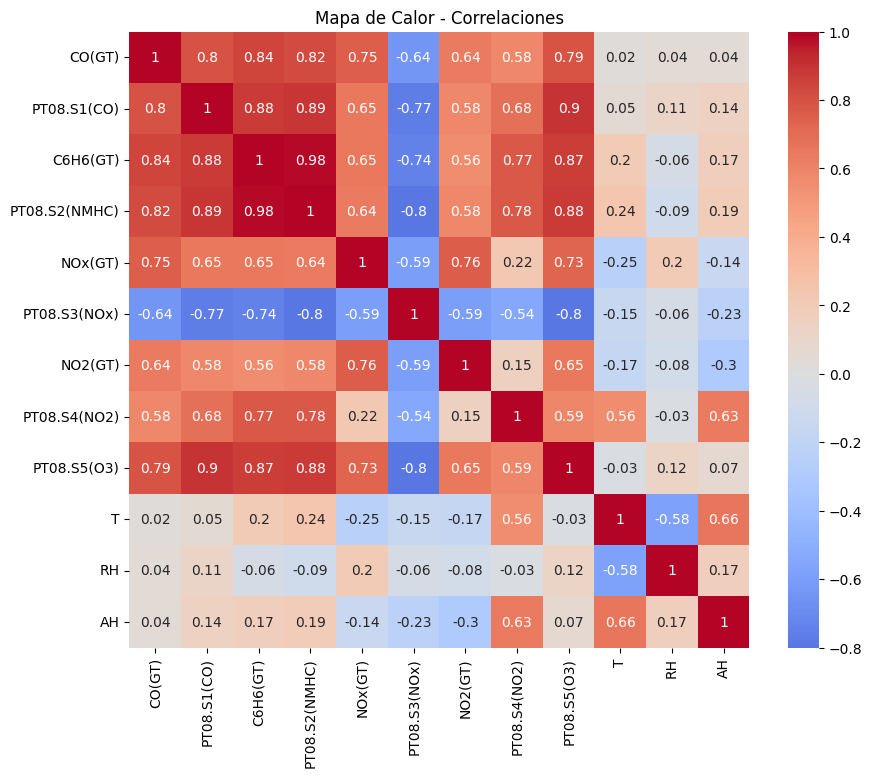

In [ ]:
## ¿cuál es la variable respuesta?¿de qué tipo es? (Recuerda justificar por qué la seleccionas)
import seaborn as sns
import matplotlib.pyplot as plt

# ANÁLISIS 1: Correlaciones (solo columnas numéricas)
df_numeric = df.select_dtypes(include=['number'])

print("CORRELACIONES:")
print(df_numeric.corr()[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']].round(2))

# ANÁLISIS 2: Distribución
print("\nESTADÍSTICOS DESCRIPTIVOS:")
print(df[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']].describe().round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr().round(2),
            annot=True,
            cmap='coolwarm',
            center=0)
plt.title('Mapa de Calor - Correlaciones')
plt.show()

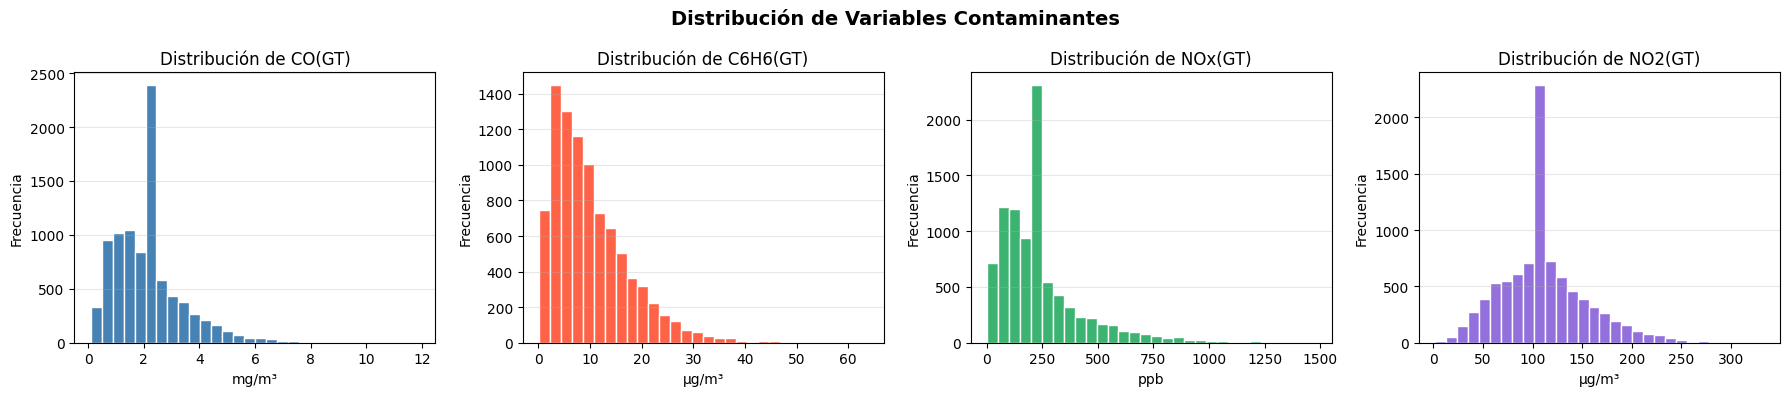

In [ ]:
# Configuración de variables
variables = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
unidades  = ['mg/m³',  'µg/m³',    'ppb',     'µg/m³']
colores   = ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple']

# Crear panel 1 fila x 4 columnas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribución de Variables Contaminantes', fontsize=14, fontweight='bold')

for ax, var, unidad, color in zip(axes, variables, unidades, colores):
    ax.hist(df[var], bins=30, color=color, edgecolor='white')
    ax.set_title(f'Distribución de {var}')
    ax.set_xlabel(unidad)
    ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Selección de la variable objetivo

Según la documentación de **UCI**, el dataset contiene **4 variables objetivo**, medidas mediante instrumentos de referencia certificados:

- **CO(GT)**: Concentración de monóxido de carbono (mg/m³)
- **C6H6(GT)**: Concentración de benceno (µg/m³)
- **NOx(GT)**: Concentración de óxidos de nitrógeno (ppb)
- **NO2(GT)**: Concentración de dióxido de nitrógeno (µg/m³)

Los valores de estas variables fueron obtenidos mediante **medidas de referencia certificada**, es decir, utilizando instrumentos de alta precisión.

### Variable seleccionada

Para este caso, se seleccionó la variable **`C6H6(GT)`** (concentración de benceno en µg/m³), en base a los siguientes criterios:

- **Correlación**  
  Según el mapa de calor, `C6H6(GT)` presenta la **correlación promedio más alta** entre las variables objetivo:
  - `PT08.S2(NMHC)`: r = 0.98  
  - `PT08.S1(CO)`: r = 0.88  
  - `PT08.S5(O3)`: r = 0.87  

- **Valores faltantes**  
  Solo presenta un **3.9% de datos faltantes**, siendo una de las variables con menor porcentaje en comparación con las demás.

- **Distribución de los datos**  
  Según el histograma, la variable presenta una distribución en un rango razonable de **0.10 a 63.70 µg/m³**, con pocos valores atípicos extremos y una **desviación estándar manejable (7.45)**.  
  En contraste, variables como `NOx(GT)` presentan muchos valores atípicos que alcanzan hasta **1500 ppb**.

- **Tipo de variable**  
  Es una **variable cuantitativa continua** (`float64`), es ideal para para problemas de regresion segun lo revisado en el Tema 4.

        CO(GT)  NOx(GT)  NO2(GT)
count  8991.00  8991.00  8991.00
mean      2.13   242.19   112.15
std       1.30   187.12    43.19
min       0.10     2.00     2.00
25%       1.20   112.00    85.00
50%       2.13   227.00   112.15
75%       2.60   280.00   132.00
max      11.90  1479.00   333.00

Asimetría (skewness):
CO(GT)     1.50
NOx(GT)    1.87
NO2(GT)    0.63
dtype: float64


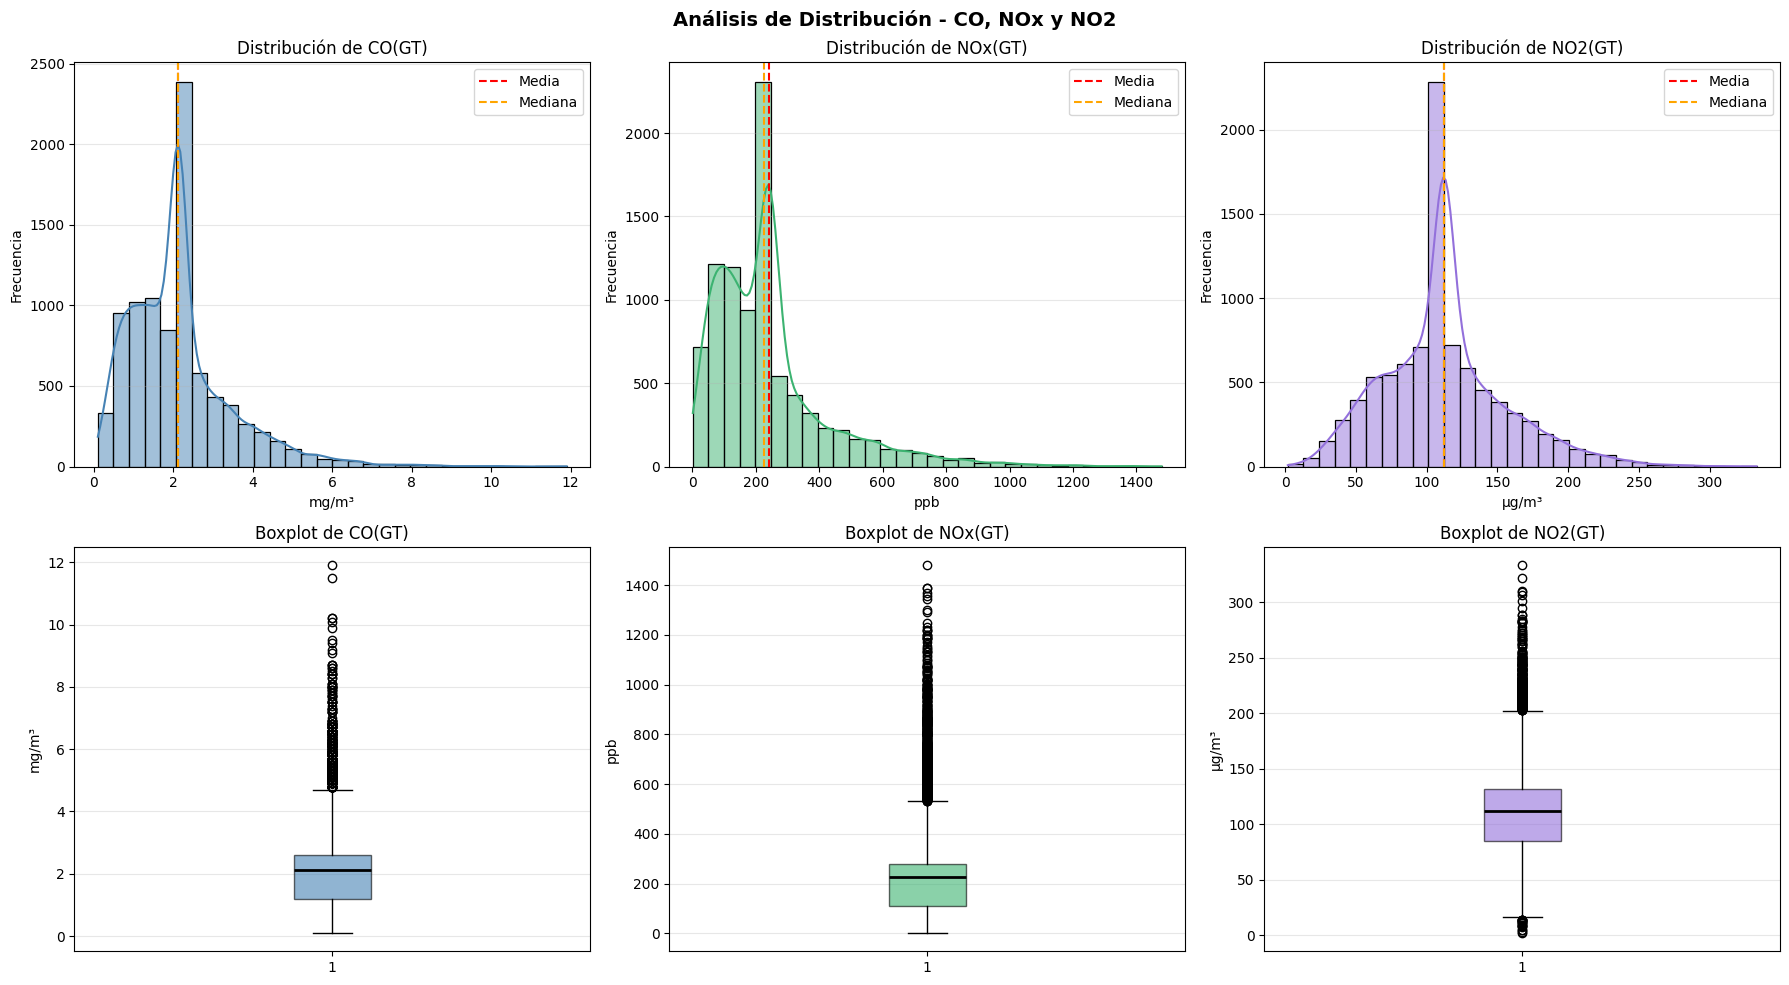

In [ ]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2?
# Estadísticos descriptivos de las 3 variables
print(df[['CO(GT)', 'NOx(GT)', 'NO2(GT)']].describe().round(2))

# Asimetría (skewness) - qué tan sesgada está la distribución
print("\nAsimetría (skewness):")
print(df[['CO(GT)', 'NOx(GT)', 'NO2(GT)']].skew().round(2))

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis de Distribución - CO, NOx y NO2',
             fontsize=14, fontweight='bold')

variables = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']
unidades  = ['mg/m³',  'ppb',     'µg/m³']
colores   = ['steelblue', 'mediumseagreen', 'mediumpurple']

# FILA 1: Histograma + curva de densidad
for i, (var, unidad, color) in enumerate(zip(variables, unidades, colores)):
    sns.histplot(df[var].dropna(), bins=30, kde=True,
                 color=color, ax=axes[0, i])
    axes[0, i].set_title(f'Distribución de {var}')
    axes[0, i].set_xlabel(unidad)
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].axvline(df[var].mean(),   color='red',    linestyle='--', label='Media')
    axes[0, i].axvline(df[var].median(), color='orange', linestyle='--', label='Mediana')
    axes[0, i].legend()
    axes[0, i].grid(axis='y', alpha=0.3)

# FILA 2: Boxplot
for i, (var, unidad, color) in enumerate(zip(variables, unidades, colores)):
    axes[1, i].boxplot(df[var].dropna(),
                       patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.6),
                       medianprops=dict(color='black', linewidth=2))
    axes[1, i].set_title(f'Boxplot de {var}')
    axes[1, i].set_ylabel(unidad)
    axes[1, i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Respuesta:

En los histogramaas se puede visualizar que las tres variables tienenn distribuciones sesgadas a la derecha que es una asimetria positiva. Esto quiere decir que la mayoria de valores se situan en rangos bajos y se expanden en un cola larga hacia valores extremos.

CO(GT) - Monóxido de carbono:
* Distribución sesgada a la derecha con un conskewness = 1.50 mayor a 0.


* Media (2.13 mg/m³) = Mediana (2.13 mg/m³) indica una distribución relativamente simétrica

* El 75% de los valores se ubican por debajo de 2.60 mg/m³

* Dispersión baja (std = 1.30), los datos se agrupan cerca de la media (2.13)

* El boxplot muestra pocos outliers por encima de 5 mg/m³


NOx(GT) - Óxidos de nitrógeno:

* Distribución muy sesgada a la derecha con un skewness = 1.87, es el mas alto de las tres variables.

* Media (242 ppb) > Mediana (227 ppb) lo que indica un sesgo pronunciado, tiene cola larga hacia la derecha.

* Dispersión muy alta (std = 187.12), tiene datos muy alejados de la media (242).

* El 75% de los valores está por debajo de 280 ppb, pero el máximo llega a 1479 ppb.

* En el boxplot se muestra una gran cantidad de outliers, esto afecta de forma negativa al modelo de regresión, este seguramente sobreestimara los valores normales.



NO2(GT) - Dióxido de nitrógeno:

* Distribución levemente sesgada con un skewness = 0.63 mas cercano a 0
* Media (112.15 µg/m³) = Mediana (112.15 µg/m³) lo que indica una distribución más simétrica como se ve en el histograma.
* Tiene una dispersión moderada (std = 43.19), con un coeficiente de variacion (43.19/112.15)x100 = 38%.
* El 75% de los valores estan por debajo de 132 µg/m³
* El boxplot muestra outliers moderados por encima de 200 µg/m³

¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

> Add blockquote



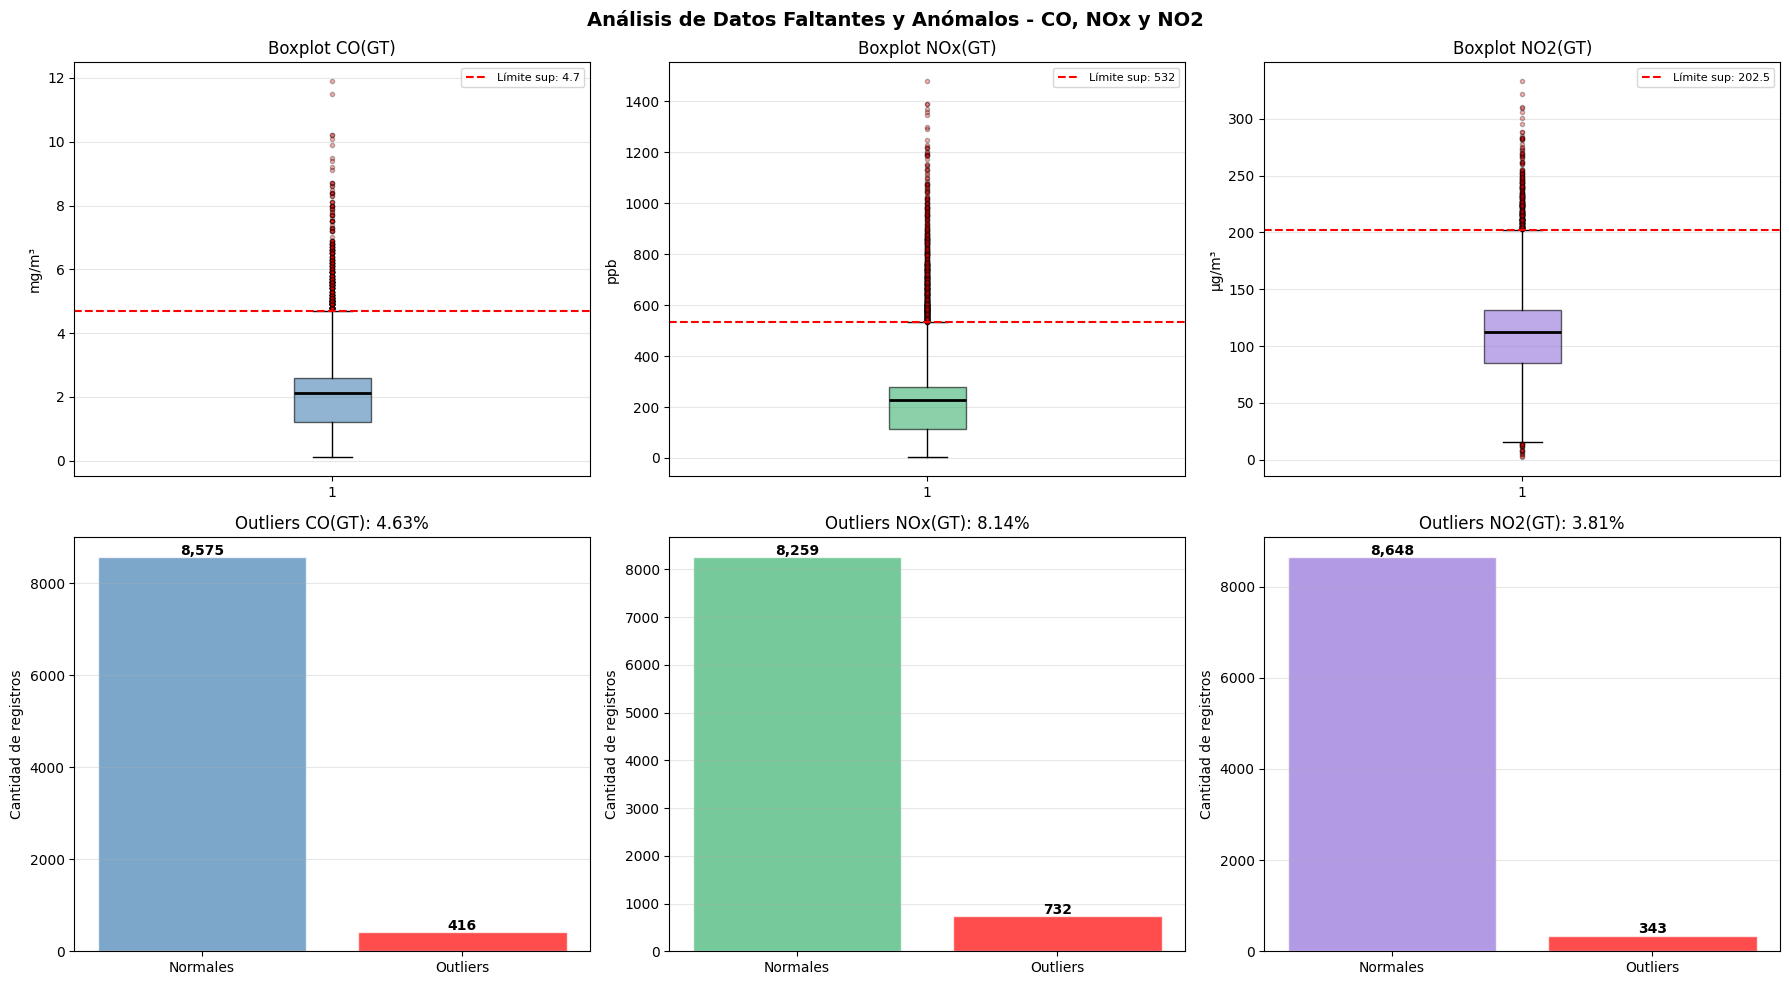

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis de Datos Faltantes y Anómalos - CO, NOx y NO2',
             fontsize=14, fontweight='bold')

variables = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']
unidades  = ['mg/m³',  'ppb',     'µg/m³']
colores   = ['steelblue', 'mediumseagreen', 'mediumpurple']

# FILA 1: Boxplot con límites IQR
limites = {
    'CO(GT)':  {'inf': -0.90, 'sup': 4.70},
    'NOx(GT)': {'inf': -140,  'sup': 532},
    'NO2(GT)': {'inf': 14.50, 'sup': 202.50}
}

for i, (var, unidad, color) in enumerate(zip(variables, unidades, colores)):
    axes[0, i].boxplot(df[var].dropna(),
                       patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.6),
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='o', markerfacecolor='red',
                                      markersize=3, alpha=0.3))
    axes[0, i].axhline(y=limites[var]['sup'], color='red',
                       linestyle='--', label=f'Límite sup: {limites[var]["sup"]}')
    axes[0, i].set_title(f'Boxplot {var}')
    axes[0, i].set_ylabel(unidad)
    axes[0, i].legend(fontsize=8)
    axes[0, i].grid(axis='y', alpha=0.3)

# FILA 2: Barras de outliers vs normales
outliers_count = [416, 732, 343]
normales_count = [len(df) - o for o in outliers_count]
porcentajes    = [4.63, 8.14, 3.81]

for i, (var, color, outlier, normal, pct) in enumerate(
        zip(variables, colores, outliers_count, normales_count, porcentajes)):

    bars = axes[1, i].bar(['Normales', 'Outliers'],
                           [normal, outlier],
                           color=[color, 'red'],
                           alpha=0.7, edgecolor='white')

    axes[1, i].set_title(f'Outliers {var}: {pct}%')
    axes[1, i].set_ylabel('Cantidad de registros')
    axes[1, i].grid(axis='y', alpha=0.3)

    # Agregar etiquetas encima de cada barra
    for bar, val in zip(bars, [normal, outlier]):
        axes[1, i].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 50,
                        f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Respuesta:**

### 1. Distribución especial
Las tres variables muestran una distribución sesgada a la derecha la mayoría de los valores se concentran en rangos bajos, con una cola hacia valores extremos (atípicos).

- **CO (GT):** *skewness* = 1.50, lo que indica una asimetría moderada.  
- **NOx (GT):** *skewness* = 1.87, lo que refleja una asimetría más pronunciada.  
- **NO₂ (GT):** *skewness* = 0.63, más cercana a una distribución normal (0).

### 2. Datos faltantes
Las tres variables tenían valores faltantes (-200), debido a fallas en los sensores químicos, según la documentación del repositorio UCI. Estos datos se trataron de la siguiente manera:

- **CO (GT):** 1,683 valores (18 %) se imputaron con la media.  
- **NOx (GT):** 1,639 valores (17.5 %) se imputaron con la media.  
- **NO₂ (GT):** 1,642 valores (17.5 %) se imputaron con la media.  

Finalmente, no quedaron valores nulos.

### 3. Datos anómalos (outliers)
Para este caso, los valores atípicos se detectaron utilizando el método IQR, donde un valor se considera anómalo si está fuera del rango  
\[Q1 − 1.5 × IQR, Q3 + 1.5 × IQR\], como se observa en las gráficas.

| Variable  | Límite superior | Outliers | % |
|-----------|-----------------|----------|----|
| CO (GT)  | 4.70 mg/m³      | 416      | 4.63 % |
| NOx (GT) | 532 ppb         | 732      | 8.14 % |
| NO₂ (GT) | 202.50 µg/m³    | 343      | 3.81 % |

Al analizar los resultados, se observa que la variable **NOx (GT)** presenta la mayor cantidad de *outliers*, con 732 registros, lo que representa el **8.14 %** del total de valores. Además según el *boxplot* se identifican valores extremos que alcanzan hasta **1479 ppb**.


In [ ]:
## ¿cómo son las correlaciones entre las variables del dataset?

CORRELACIONES CON C6H6(GT) - Variable objetivo:
--------------------------------------------------
C6H6(GT)         1.00
PT08.S2(NMHC)    0.98
PT08.S1(CO)      0.88
PT08.S5(O3)      0.87
CO(GT)           0.84
PT08.S4(NO2)     0.77
NOx(GT)          0.65
NO2(GT)          0.56
T                0.20
AH               0.17
RH              -0.06
PT08.S3(NOx)    -0.74
Name: C6H6(GT), dtype: float64

VARIABLES ALTAMENTE CORRELACIONADAS (|r| > 0.70):
--------------------------------------------------
CO(GT)               ↔ PT08.S1(CO)          r = 0.80
CO(GT)               ↔ C6H6(GT)             r = 0.84
CO(GT)               ↔ PT08.S2(NMHC)        r = 0.82
CO(GT)               ↔ NOx(GT)              r = 0.75
CO(GT)               ↔ PT08.S5(O3)          r = 0.79
PT08.S1(CO)          ↔ C6H6(GT)             r = 0.88
PT08.S1(CO)          ↔ PT08.S2(NMHC)        r = 0.89
PT08.S1(CO)          ↔ PT08.S3(NOx)         r = -0.77
PT08.S1(CO)          ↔ PT08.S5(O3)          r = 0.90
C6H6(GT)             ↔ PT0

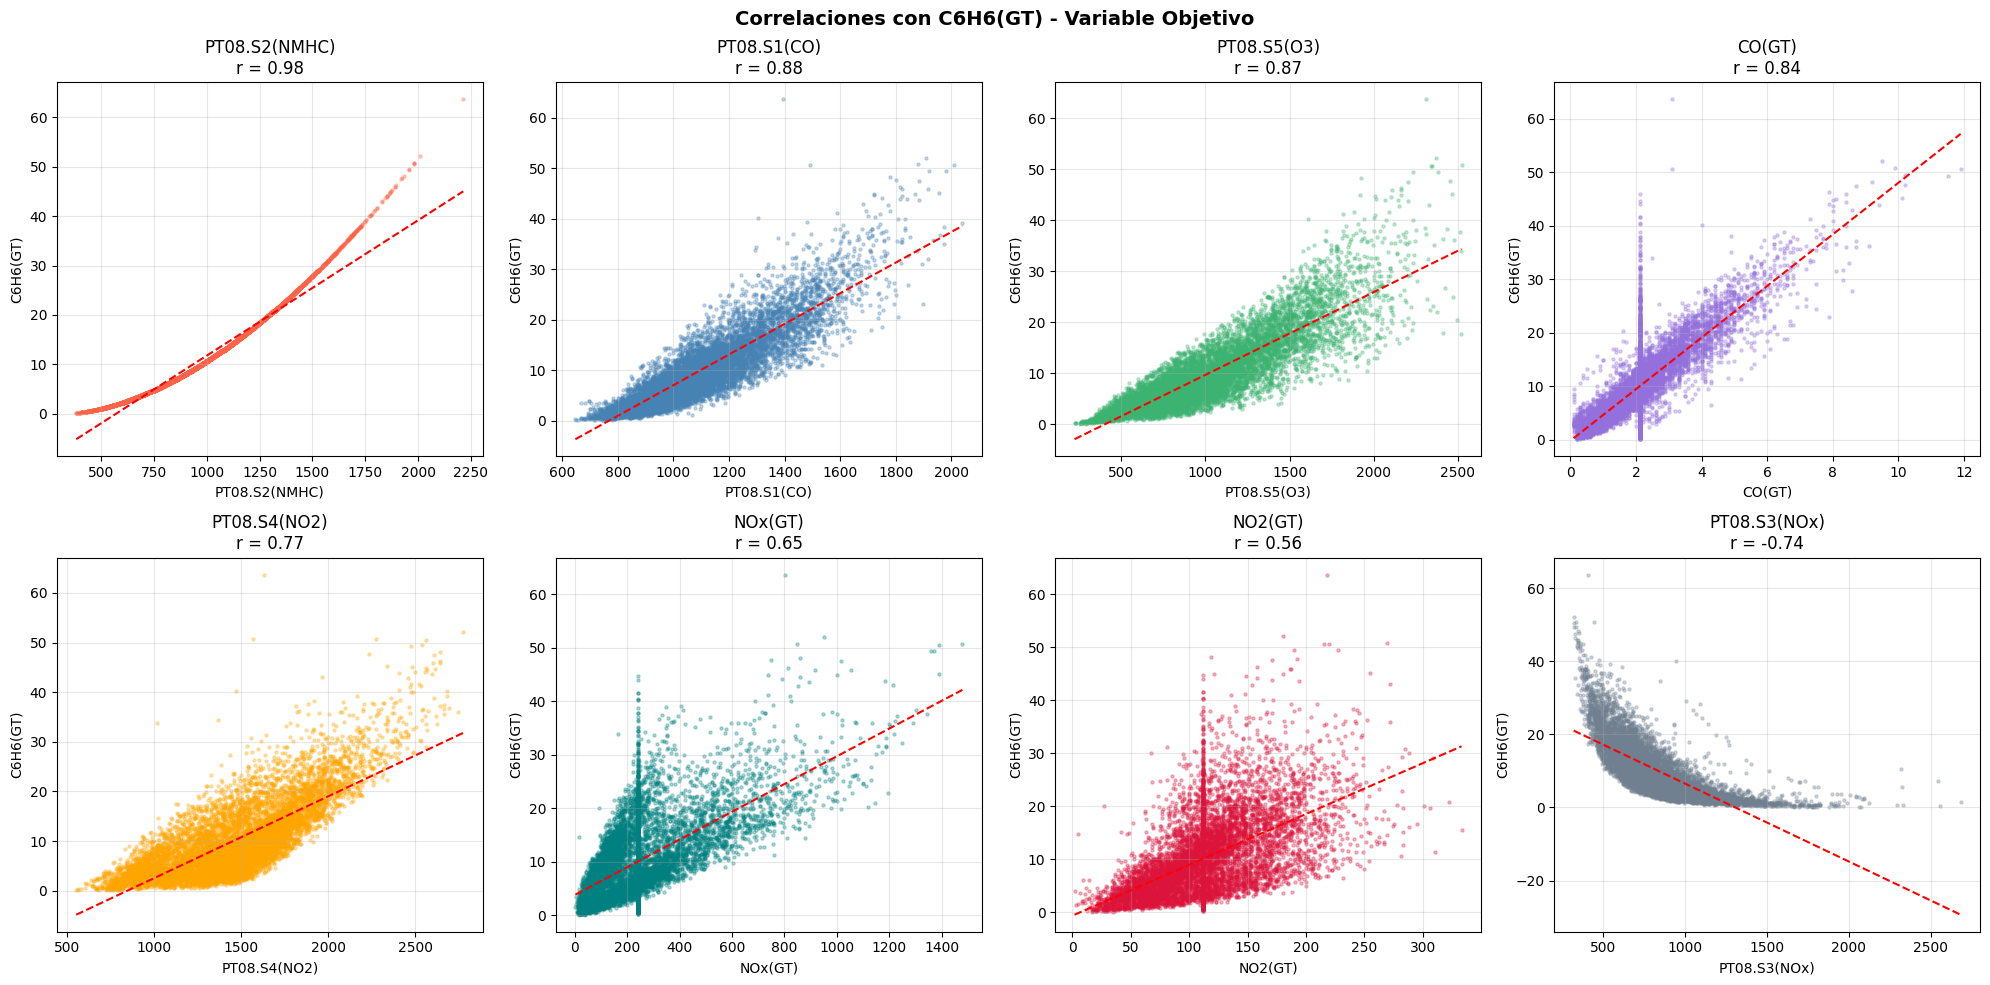

In [ ]:
# Correlaciones ordenadas por valor absoluto
print("CORRELACIONES CON C6H6(GT) - Variable objetivo:")
print("-"*50)
correlaciones = df_numeric.corr()['C6H6(GT)'].sort_values(ascending=False)
print(correlaciones.round(2))

print("\nVARIABLES ALTAMENTE CORRELACIONADAS (|r| > 0.70):")
print("-"*50)
for i in range(len(df_numeric.corr().columns)):
    for j in range(i+1, len(df_numeric.corr().columns)):
        r = df_numeric.corr().iloc[i, j]
        if abs(r) > 0.70:
            var1 = df_numeric.corr().columns[i]
            var2 = df_numeric.corr().columns[j]
            print(f"{var1:20} ↔ {var2:20} r = {r:.2f}")


fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Correlaciones con C6H6(GT) - Variable Objetivo',
             fontsize=14, fontweight='bold')

# Top 8 variables más correlacionadas con C6H6(GT)
top_vars = ['PT08.S2(NMHC)', 'PT08.S1(CO)', 'PT08.S5(O3)',
            'CO(GT)', 'PT08.S4(NO2)', 'NOx(GT)', 'NO2(GT)', 'PT08.S3(NOx)']
colores  = ['tomato', 'steelblue', 'mediumseagreen', 'mediumpurple',
            'orange', 'teal', 'crimson', 'slategray']

for i, (var, color) in enumerate(zip(top_vars, colores)):
    fila = i // 4
    col  = i  % 4

    axes[fila, col].scatter(df[var], df['C6H6(GT)'],
                            alpha=0.3, color=color, s=5)

    # Línea de tendencia
    z = np.polyfit(df[var].dropna(),
                   df['C6H6(GT)'].dropna(), 1)
    p = np.poly1d(z)
    axes[fila, col].plot(sorted(df[var].dropna()),
                         p(sorted(df[var].dropna())),
                         "r--", linewidth=1.5)

    r = df_numeric.corr()['C6H6(GT)'][var]
    axes[fila, col].set_title(f'{var}\nr = {r:.2f}')
    axes[fila, col].set_xlabel(var)
    axes[fila, col].set_ylabel('C6H6(GT)')
    axes[fila, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Respuesta:**

### Análisis de correlaciones
Para el análisis de las correlaciones entre las variables se utilizó el **coeficiente de Pearson** el cual toma valores entre **−1 y 1** se apoya en la visualización mediante **diagramas de dispersión**.

### Correlaciones con la variable objetivo **C6H6 (GT)**

| Variable              | r     | Interpretación        |
|-----------------------|-------|-----------------------|
| PT08.S2 (NMHC)        | 0.98  | Casi perfecta         |
| PT08.S1 (CO)          | 0.88  | Muy alta              |
| PT08.S5 (O₃)          | 0.87  | Muy alta              |
| CO (GT)               | 0.84  | Alta                  |
| PT08.S4 (NO₂)         | 0.77  | Alta                  |
| NOx (GT)              | 0.65  | Moderada              |
| NO₂ (GT)              | 0.56  | Moderada              |
| T                     | 0.20  | Baja                  |
| AH                    | 0.17  | Baja                  |
| RH                    | -0.06 | Sin correlación       |
| PT08.S3 (NOx)         | -0.74 | Alta negativa         |

### Correlaciones entre variables predictoras
Se consideraron correlaciones altas aquellas con **r > 0.70**.  
Se obtuvieron **19 pares de variables altamente correlacionadas**, las cuales, según lo revisado en el tema 3.2, podrían presentar **redundancia**. A continuación, se listan las más destacadas:

- **C6H6 (GT) – PT08.S2 (NMHC):** r = 0.98 (casi perfecta)  
- **PT08.S1 (CO) – PT08.S5 (O₃):** r = 0.90  
- **PT08.S1 (CO) – PT08.S2 (NMHC):** r = 0.89  
- **PT08.S3 (NOx) – PT08.S5 (O₃):** r = -0.80 (negativa)  
- **PT08.S2 (NMHC) – PT08.S3 (NOx):** r = -0.80 (negativa)

### Interpretación según los diagramas de dispersión
- **PT08.S2 (NMHC)** presenta una relación **curvilínea** con **C6H6 (GT)** (r = 0.98), donde los puntos siguen una curva pronunciada.  
- **PT08.S1 (CO)**, **PT08.S5 (O₃)** y **CO (GT)** muestran una **relación lineal positiva** clara.  
- **PT08.S3 (NOx)** presenta una **relación lineal negativa** (r = -0.74), es decir, a mayor valor del sensor NOx, menor concentración de benceno (C6H6 (GT)).  
- Las variables **T**, **RH** y **AH** no muestran una correlación clara con **C6H6 (GT)**.

In [ ]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?

**Respuesta**

### Correlaciones con la variable objetivo **C6H6 (GT)**

| Variable       | r     | Interpretación  |
|----------------|-------|-----------------|
| PT08.S2 (NMHC) | 0.98  | Casi perfecta   |
| PT08.S1 (CO)   | 0.88  | Muy alta        |
| PT08.S5 (O₃)   | 0.87  | Muy alta        |
| CO (GT)        | 0.84  | Alta            |
| PT08.S4 (NO₂)  | 0.77  | Alta            |
| NOx (GT)       | 0.65  | Moderada        |
| NO₂ (GT)       | 0.56  | Moderada        |
| T              | 0.20  | Baja            |
| AH             | 0.17  | Baja            |
| RH             | -0.06 | Sin correlación |
| PT08.S3 (NOx)  | -0.74 | Alta negativa   |

Según los resultados obtenidos en la pregunta anterior, las **tres variables más correlacionadas con la variable objetivo** son:

- **PT08.S2 (NMHC):** r = 0.98, presenta una correlación casi perfecta. El sensor de hidrocarburos no metánicos es el mejor predictor del benceno.  
- **PT08.S1 (CO):** r = 0.88, muestra una correlación muy alta. El sensor de monóxido de carbono tiene una fuerte relación con el benceno.  
- **PT08.S5 (O₃):** r = 0.87, tiene una correlación muy alta. El sensor de ozono también muestra una relación fuerte con el benceno.

Finalmente, estas tres variables se usarán como las principales para la **predicción en el modelo de regresión lineal**. Según el tema 3.2, una correlación alta indica que la variable contiene **información útil para predecir la variable objetivo**.

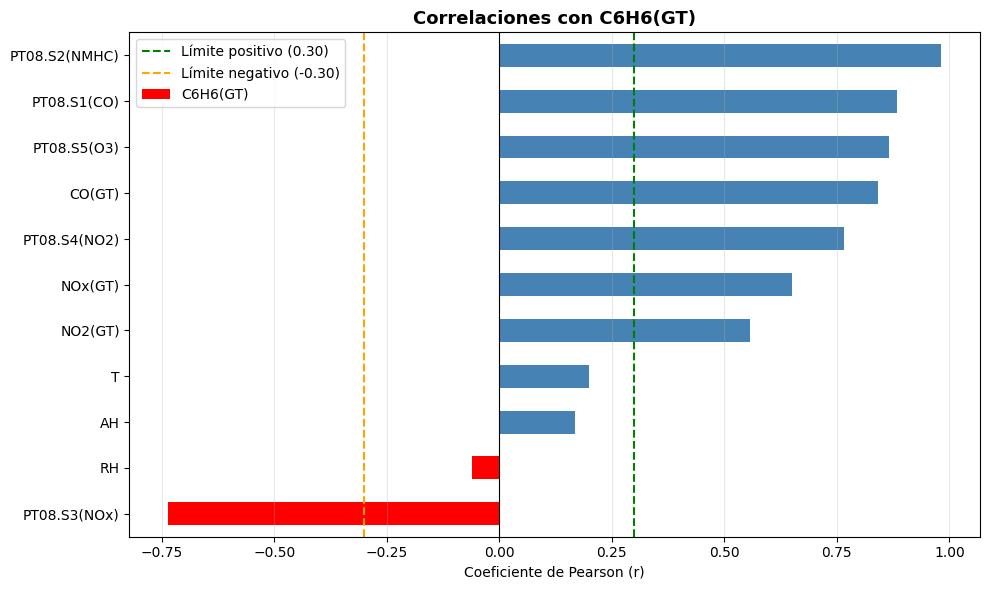

In [ ]:
## ¿existe alguna variable que no tenga correlación?
# Visualizar correlaciones con C6H6(GT) ordenadas
correlaciones = df_numeric.corr()['C6H6(GT)'].drop('C6H6(GT)').sort_values()

plt.figure(figsize=(10, 6))
colores = ['red' if x < 0 else 'steelblue' for x in correlaciones]
correlaciones.plot(kind='barh', color=colores)
plt.axvline(x=0.30,  color='green', linestyle='--', label='Límite positivo (0.30)')
plt.axvline(x=-0.30, color='orange', linestyle='--', label='Límite negativo (-0.30)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Correlaciones con C6H6(GT)', fontsize=13, fontweight='bold')
plt.xlabel('Coeficiente de Pearson (r)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Respuesta:**

Según el gráfico de correlaciones con **C6H6 (GT)**, se lograron identificar **tres variables con correlación baja o nula** (r < 0.30):

- **RH:** r = -0.06, no presenta correlación.  
- **AH:** r = 0.17, presenta una correlación muy baja.  
- **T:** r = 0.20, presenta una correlación muy baja.  

### Análisis de los resultados

- **RH (Humedad relativa):**  
  Con r = -0.06, esta variable es independiente de **C6H6 (GT)**. Según lo visto en el *Tema 3.2* cuando el coeficiente de correlación es cercano a 0 los atributos pueden considerarse independientes, eso quiere decir que esta variable no aporta información útil para predecir el benceno.

- **AH (Humedad absoluta) y T (Temperatura):**  
  Con r = 0.17 y r = 0.20 ambas variables presentan una correlación muy baja, es insuficiente para
  realizar predicciones de la variable objetivo.

- **PT08.S3 (NOx):**  
  Tiene r = -0.74, lo que indica una **correlación negativa alta**. Esta correlación es alta pero es inversa, por lo que cuando aumenta el valor del sensor de NOx se disminuye la concentración de benceno (**C6H6 (GT)**).


Las variables **RH**, **AH** y **T** se deberian eliminar del modelo de regresión porque no aportan información util para predecir **C6H6 (GT)**. Si se usan podrían introducir datos inutiles al modelo y su precision no seria buena.

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

**Respuesta:**

### Suposiciones:

* Los datos faltantes (-200) corresponden a fallas del sensor, por lo que no son relevantes, y pasarlos a NaN es lo ideal.

* Según lo revisado, existe una relación lineal entre los sensores y la variable objetivo **C6H6 (GT)**, sobre todo con **PT08.S2 (NMHC)** (r = 0.98).

* Los valores atípicos detectados, según la documentación del repositorio UCI, sí son valores reales y no errores de medición ni fallas de sensores, por lo que se mantienen en el *dataset*.

* Para el entrenamiento del modelo, se deberían normalizar las variables, ya que tienen escalas diferentes.

### Conclusiones:

* Las variables que se usarían en el modelo son: **PT08.S2 (NMHC), PT08.S1 (CO), PT08.S5 (O3), CO (GT), PT08.S4 (NO2), NOx (GT), NO2 (GT)**.  
  Se descartarían las variables **RH**, **AH** y **T** por su correlación < 0.30, así como también **Date** y **Time**.

* Se usará **C6H6 (GT)** como variable objetivo porque es una variable cuantitativa continua, lo que la hace ideal para regresión lineal.

* Los tipos de modelos: para **regresión lineal simple** se usaría **PT08.S2 (NMHC)** con r = 0.98, y para **regresión lineal múltiple** se usarían las siete variables seleccionadas.

* **Métricas de evaluación:**  
  Se evaluará con **RMSE**, **MAE** y **R²**.  
  Se dividirá el *dataset* en **80 % train / 20 % test**.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

El algoritmo de Regresión Lineal, necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primer modelo que se debe construir, usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from pandas import DataFrame


scaler = StandardScaler()

X_train = DataFrame(scaler.fit_transform(X_train))
X_test = DataFrame(scaler.fit_transform(X_test))

In [ ]:
# separar datos de entrenamiento y test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['PT08.S2(NMHC)', 'PT08.S1(CO)', 'PT08.S5(O3)',
        'CO(GT)', 'PT08.S4(NO2)', 'NOx(GT)', 'NO2(GT)']]
y = df['C6H6(GT)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Se dividió el dataset en 80 % para entrenamiento y 20 % para test.

Se usa **StandardScaler** para convertir todas las variables a una escala común con media = 0 y std = 1; esto evita que variables con valores grandes, como 0 a 2500, dominen sobre valores más bajos, como CO: 0–12.

También se definen las variables:

* **Las predictoras (X):** estas las usará el modelo para aprender y predecir. Se seleccionan 7 según el EDA, las cuales son: PT08.S2(NMHC), PT08.S1(CO), PT08.S5(O3),  
  CO(GT), PT08.S4(NO2), NOx(GT), NO2(GT). Estas obtuvieron la mejor correlación con la variable objetivo C6H6(GT).

* **La variable objetivo (y):** esta es la que el modelo intentará predecir se eligió esta porque tuvo la mejor correlación con los sensores (r = 0.98), tiene menos valores faltantes (3.9 %) y es una variable cuantitativa continua.


In [ ]:
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción

# Seleccionar solo PT08.S2(NMHC)
X_train_simple = X_train[['PT08.S2(NMHC)']].values
X_train_simple = scaler.fit_transform(X_train_simple)

X_test_simple  = X_test[['PT08.S2(NMHC)']].values
X_test_simple  = scaler.transform(X_test_simple)

print("Variable seleccionada: PT08.S2(NMHC)")
print(f"Correlación con C6H6(GT): r = 0.98")
print(f"Shape X_train_simple: {X_train_simple.shape}")
print(f"Shape X_test_simple:  {X_test_simple.shape}")

Variable seleccionada: PT08.S2(NMHC)
Correlación con C6H6(GT): r = 0.98
Shape X_train_simple: (7192, 1)
Shape X_test_simple:  (1799, 1)


Según el análisis con EDA se escogió la variable **PT08.S2 (NMHC)**. Esta selección se basó en los siguientes criterios.

1. Tuvo la mayor correlación (r = 0.98) con la variable objetivo **C6H6 (GT)**.  

2. En el diagrama de dispersión se mostró una relación muy alta, casi perfecta, entre **PT08.S2 (NMHC)** y **C6H6 (GT)**.  

3. Es una variable de tipo cuantitativa que mide la respuesta del sensor de hidrocarburos no metánicos; está relacionada directamente con el benceno químicamente.

In [ ]:
# entrena el modelo con los datos de entrenamiento
from sklearn.linear_model import LinearRegression

# Crear y entrenar el modelo
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_simple, y_train)

print(" Modelo entrenado correctamente")

 Modelo entrenado correctamente


Se usa LinearRegression() que crea el modelo de regresion lineal simple.

Con .fit(X_train_simple, y_train) se realiza el entrenamiento de acuerdo a:
* Toma los datos de entrenamiento X_train_simple (PT08.S2(NMHC))
* Los compara con los valores reales y_train (C6H6(GT))
* Calcula los parámetros β0 y β1 que minimizan el error usando el método de mínimos cuadrados (Tema 4.2).

In [ ]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?

print("PARÁMETROS APRENDIDOS (Tema 4.2):")
print("="*45)
print(f"β0 - Intercepto:  {modelo_simple.intercept_:.4f}")
print(f"β1 - Coeficiente: {modelo_simple.coef_[0]:.4f}")
print(f"\nEcuación del modelo:")
print(f"C6H6(GT) = {modelo_simple.intercept_:.4f} + "
      f"{modelo_simple.coef_[0]:.4f} × PT08.S2(NMHC)")

PARÁMETROS APRENDIDOS (Tema 4.2):
β0 - Intercepto:  9.9962
β1 - Coeficiente: 7.2789

Ecuación del modelo:
C6H6(GT) = 9.9962 + 7.2789 × PT08.S2(NMHC)


Según el **Tema 4.2**, el modelo de **regresión lineal simple** aprendió los siguientes parámetros de la fórmula:

f(x) = y = β0 + β1X + ε

Aplicado al modelo entrenado:

**C6H6 (GT) = 9.9962 + 7.2789 × PT08.S2 (NMHC)**

* **β0 = 9.9962 (Intersección):**  
  Representa el valor estimado de **C6H6 (GT)** cuando el sensor **PT08.S2 (NMHC)** se encuentra en su valor promedio en la escala normalizada *Z-score*. Esto quiere decir que, cuando el sensor está en un valor normal el benceno estimado es **9.99 µg/m³**.

* **β1 = 7.2789 (Pendiente):**  
  Indica que por cada unidad que aumenta **PT08.S2 (NMHC)** en la escala normalizada, la concentración de benceno **C6H6 (GT)** incrementa en **7.2789 µg/m³**.  
  En palabras simples, si el sensor detecta mayor contaminación, el modelo predice un aumento en el benceno. Tanto el valor de **β1** como **r = 0.98** confirman esta relación.

Explica qué indican estos parámetros

_indica aquí tu respuesta_

PREDICCIONES vs VALORES REALES:
      Real   Predicho   Diferencia
---------------------------------------------
      8.60       9.64        -1.04
     29.70      26.62         3.08
      9.30      10.41        -1.11
      2.40       1.20         1.20
      8.10       9.10        -1.00
      9.10      10.25        -1.15
      6.90       7.68        -0.78
      6.00       6.56        -0.56
     28.00      25.50         2.50
      3.20       2.62         0.58


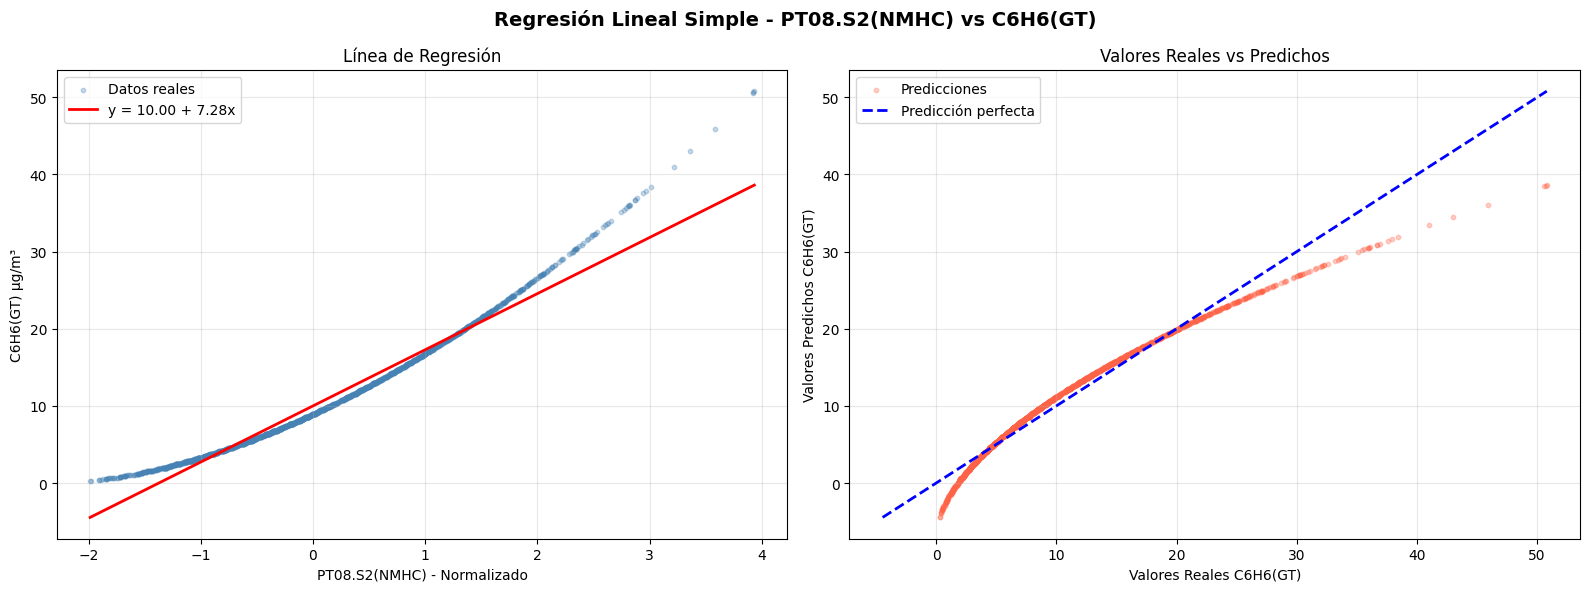

In [ ]:
# realiza las predicciones para el conjunto de datos de test

# PASO 1: Realizar predicciones
y_pred_simple = modelo_simple.predict(X_test_simple)

# PASO 2: Ver primeras 10 predicciones vs valores reales
print("PREDICCIONES vs VALORES REALES:")
print("="*45)
print(f"{'Real':>10} {'Predicho':>10} {'Diferencia':>12}")
print("-"*45)
for real, pred in zip(y_test[:10], y_pred_simple[:10]):
    diff = real - pred
    print(f"{real:>10.2f} {pred:>10.2f} {diff:>12.2f}")

# PASO 3: Gráficas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Regresión Lineal Simple - PT08.S2(NMHC) vs C6H6(GT)',
             fontsize=14, fontweight='bold')

# GRÁFICA 1: Puntos reales + línea de regresión (Tema 4.2)
axes[0].scatter(X_test_simple, y_test,
                alpha=0.3, color='steelblue', s=10, label='Datos reales')

x_linea = np.linspace(X_test_simple.min(), X_test_simple.max(), 100)
y_linea = modelo_simple.intercept_ + modelo_simple.coef_[0] * x_linea
axes[0].plot(x_linea, y_linea, color='red', linewidth=2,
             label=f'y = {modelo_simple.intercept_:.2f} + {modelo_simple.coef_[0]:.2f}x')

axes[0].set_xlabel('PT08.S2(NMHC) - Normalizado')
axes[0].set_ylabel('C6H6(GT) µg/m³')
axes[0].set_title('Línea de Regresión')
axes[0].legend()
axes[0].grid(alpha=0.3)

# GRÁFICA 2: Valores reales vs predichos (Tema 4.5)
axes[1].scatter(y_test, y_pred_simple,
                alpha=0.3, color='tomato', s=10, label='Predicciones')

lims = [min(y_test.min(), y_pred_simple.min()),
        max(y_test.max(), y_pred_simple.max())]
axes[1].plot(lims, lims, 'b--', linewidth=2, label='Predicción perfecta')

axes[1].set_xlabel('Valores Reales C6H6(GT)')
axes[1].set_ylabel('Valores Predichos C6H6(GT)')
axes[1].set_title('Valores Reales vs Predichos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Se tomaron tres filas de la tabla de predicciones, en donde el residuo (diferencia) entre los valores reales y los predichos es el siguiente:

- **Real = 8.60**, **Predicho = 9.64**, **Diferencia = -1.04**  el modelo sobreestimó.  
- **Real = 29.70**, **Predicho = 26.62**, **Diferencia = 3.08**  el modelo subestimó.  
- **Real = 2.40**, **Predicho = 1.20**, **Diferencia = 1.20**  el modelo subestimó.

Según los resultados analizados, el modelo sobreestimó algunos valores, calculando más de lo real, y subestimó otros calculando menos de lo real.

### En base a las gráficas:

**Gráfica línea de regresión:**
- Los puntos azules son los valores reales.  
- La línea roja corresponde a las predicciones del modelo.  
- Se puede observar que los valores reales siguen una curva, pero el modelo intenta ajustar una línea recta.  
- Por esta razón existen diferencias entre los valores reales y los predichos.

**Gráfica valores reales vs. predichos:**
- La línea azul punteada representa la predicción perfecta (real = predicho).  
- Los puntos rojos representan las predicciones del modelo.  
- Los puntos rojos se mantienen cerca de la línea perfecta en valores bajos (0–20 µg/m³).  
- En valores altos (> 20 µg/m³) el modelo está subestimando.

Finalmente, se puede observar que el modelo realiza predicciones razonablemente buenas utilizando la variable **PT08.S2 (NMHC)**, pero subestima los valores altos, lo cual según lo revisado se debe a que la relación entre el sensor y el benceno es ligeramente curvilínea y no perfectamente lineal.



In [ ]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso? Justifica tu respuesta.

Para evaluar el modelo se utilizarán **MAE**, **RMSE** y **R²**, según el **Tema 4.3**:

* **MAE:** es la métrica principal porque el *dataset* contiene *outliers* reales que representan picos de contaminación, según la documentación del repositorio UCI. Al no penalizarlos de forma desproporcionada, refleja mejor el error promedio real del modelo en µg/m³.

* **RMSE:** complementa al MAE al mostrar el impacto de los errores grandes en el modelo. Se expresa en las mismas unidades que **C6H6 (GT)** (µg/m³).

* **R²:** indica qué proporción de la varianza de **C6H6 (GT)** es explicada por el modelo. Un valor cercano a 1 indica un buen ajuste.

In [ ]:
# ¿Qué error tiene el modelo? Explícalo.

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calcular métricas (Tema 4.3)
mae  = mean_absolute_error(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_simple)

print("MÉTRICAS - REGRESIÓN LINEAL SIMPLE")
print("="*40)
print(f"MAE:  {mae:.4f}  µg/m³")
print(f"MSE:  {mse:.4f}  µg/m³²")
print(f"RMSE: {rmse:.4f}  µg/m³")
print(f"R²:   {r2:.4f}")

MÉTRICAS - REGRESIÓN LINEAL SIMPLE
MAE:  1.0135  µg/m³
MSE:  2.0016  µg/m³²
RMSE: 1.4148  µg/m³
R²:   0.9652


En base a los resultados de error obtenidos del modelo de Regresion Lineal Simple usando PT08.S2(NMHC) como variable predictora muestra un desempeño muy bueno:

* MAE = 1.01 µg/m³, presenta un error promedio muy bajo considerando el rango de la variable (0.10 - 63.70 µg/m³)
* RMSE = 1.41 µg/m³, es ligeramente mayor al MAE, indica la presencia de algunos errores grandes producidos por los outliers reales del dataset.
* R² = 0.9652, el modelo explica el 96.52% de la varianza de C6H6(GT), lo que indica que este realiza un muy bien ajuste de los valores predichos.

Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con **todas las variables** del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

In [ ]:
# Se usan todas las variables (ya están en X_train_scaled y X_test_scaled)
# X contiene: PT08.S2(NMHC), PT08.S1(CO), PT08.S5(O3),
#             CO(GT), PT08.S4(NO2), NOx(GT), NO2(GT)
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_scaled, y_train)
print("Modelo múltiple entrenado correctamente")

Modelo múltiple entrenado correctamente


In [ ]:
# Parámetros aprendidos
print("\nPARÁMETROS APRENDIDOS:")
print("="*50)
print(f"Intercepto (β0): {modelo_multiple.intercept_:.4f}")
print("\nCoeficientes:")
for var, coef in zip(X.columns, modelo_multiple.coef_):
    print(f"  {var:20}: β = {coef:.4f}")


PARÁMETROS APRENDIDOS:
Intercepto (β0): 9.9962

Coeficientes:
  PT08.S2(NMHC)       : β = 6.8458
  PT08.S1(CO)         : β = 0.2107
  PT08.S5(O3)         : β = -0.2701
  CO(GT)              : β = 0.6825
  PT08.S4(NO2)        : β = -0.0382
  NOx(GT)             : β = 0.4990
  NO2(GT)             : β = -0.6317


In [ ]:
#Predicciones
y_pred_multiple = modelo_multiple.predict(X_test_scaled)

In [ ]:
# PASO 5: Primeras 10 predicciones vs reales
print("\nPREDICCIONES vs VALORES REALES:")
print("="*45)
print(f"{'Real':>10} {'Predicho':>10} {'Diferencia':>12}")
print("-"*45)
for real, pred in zip(y_test[:10], y_pred_multiple[:10]):
    diff = real - pred
    print(f"{real:>10.2f} {pred:>10.2f} {diff:>12.2f}")


PREDICCIONES vs VALORES REALES:
      Real   Predicho   Diferencia
---------------------------------------------
      8.60       9.01        -0.41
     29.70      27.12         2.58
      9.30      10.33        -1.03
      2.40       0.92         1.48
      8.10       8.84        -0.74
      9.10       9.79        -0.69
      6.90       7.38        -0.48
      6.00       6.78        -0.78
     28.00      25.39         2.61
      3.20       2.67         0.53


In [ ]:
# Métricas
mae  = mean_absolute_error(y_test, y_pred_multiple)
mse  = mean_squared_error(y_test, y_pred_multiple)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_multiple)

print("\nMÉTRICAS - REGRESIÓN LINEAL MÚLTIPLE")
print("="*40)
print(f"MAE:  {mae:.4f}  µg/m³")
print(f"MSE:  {mse:.4f}  µg/m³²")
print(f"RMSE: {rmse:.4f}  µg/m³")
print(f"R²:   {r2:.4f}")


MÉTRICAS - REGRESIÓN LINEAL MÚLTIPLE
MAE:  0.9256  µg/m³
MSE:  1.6765  µg/m³²
RMSE: 1.2948  µg/m³
R²:   0.9708


¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

Según los resultados obtenidos, el modelo de **Regresión Lineal Múltiple** con 7 variables mejora todas las métricas analizadas frente al modelo simple:

* **MAE** bajó de **1.01** a **0.93 µg/m³** (−8.7 %).  
* **RMSE** bajó de **1.41** a **1.29 µg/m³** (−8.5 %).  
* **R²** subió de **0.9652** a **0.9708** (+0.56 %).

Se concluye que usar más variables predictoras ayuda al modelo a obtener más información útil para predecir la variable objetivo **C6H6 (GT)** y mejora la precisión de las predicciones.

#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algoritmo **DTRegressor** necesita ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

**Indica qué son cada uno de estos hiperparámetros**

- **criterion:**  
  Es la función que utiliza el árbol para medir la calidad de la división. Sus opciones son:
  - `squared_error`: usa el error cuadrático medio (MSE).
  - `absolute_error`: usa el error absoluto medio (MAE).
  - `friedman_mse`: versión mejorada del MSE.

- **splitter:**  
  Es la estrategia para elegir la división en cada nodo. Tiene las siguientes opciones:
  - `best`: elige la mejor división posible, es más preciso.
  - `random`: elige una división aleatoria, es más rápido.

- **max_depth:**  
  Indica cuántos niveles tendrá el árbol.

- **min_samples_split:**  
  Indica el número mínimo de muestras necesarias para dividir un nodo, es decir, controla cuándo se puede dividir un nodo.

- **min_samples_leaf:**  
  Indica el tamaño mínimo de los nodos finales (hojas).

- **max_features:**  
  Indica el número máximo de variables que considera el árbol para encontrar la mejor división.


Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

* Indica el umbral mínimo de mejora que debe lograr una división para que el árbol la realice; por ejemplo, para `min_impurity_decrease = 0.5`, divide solo si la mejora es de al menos 0.5.

* Evita que el árbol realice divisiones que no mejorarían el modelo; con esto se reduce el *overfitting*.


Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

**Modelo 1**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# MODELO 1: Árbol de decisión con hiperparámetros especificados
modelo_arbol1 = DecisionTreeRegressor(
    criterion='poisson',      # criterio de partición
    max_depth=10,             # profundidad máxima
    min_samples_split=10,     # mínimo de ejemplos para dividir
    min_samples_leaf=2,       # mínimo de ejemplos en hoja
    max_features=None,        # todas las características
    random_state=42
)

In [ ]:
# Entrenar
modelo_arbol1.fit(X_train_scaled, y_train)
print("Árbol de decisión 1 entrenado correctamente")

Árbol de decisión 1 entrenado correctamente


In [ ]:
# Predicciones
y_pred_arbol1 = modelo_arbol1.predict(X_test_scaled)

Calcula MAE, R2 y RMSLE

In [ ]:
mae  = mean_absolute_error(y_test, y_pred_arbol1)
mse  = mean_squared_error(y_test, y_pred_arbol1)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_arbol1)

print("\nMÉTRICAS - ÁRBOL DE DECISIÓN 1")
print("="*40)
print(f"Criterion:          poisson")
print(f"Max depth:          10")
print(f"Min samples split:  10")
print(f"Min samples leaf:   2")
print(f"Max features:       None (todas)")
print(f"\nMAE:  {mae:.4f}  µg/m³")
print(f"MSE:  {mse:.4f}  µg/m³²")
print(f"RMSE: {rmse:.4f}  µg/m³")
print(f"R²:   {r2:.4f}")


MÉTRICAS - ÁRBOL DE DECISIÓN 1
Criterion:          poisson
Max depth:          10
Min samples split:  10
Min samples leaf:   2
Max features:       None (todas)

MAE:  0.0168  µg/m³
MSE:  0.0103  µg/m³²
RMSE: 0.1017  µg/m³
R²:   0.9998


¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

**Respuesta**

Para validar si existe *overfitting*, se compararon las métricas del modelo en **TRAIN vs TEST** dando lo siguiente:

## Validación de overfitting

Se puede observar que la diferencia entre **TEST** y **TRAIN** es casi nula, lo que quiere decir que el modelo no presenta *overfitting*. En caso de que sí lo presentara se darían resultados similares a los siguientes:

### Sin overfitting
- TRAIN R² = 0.9998  
- TEST  R² = 0.9998  
- La diferencia es de 0.

### Con overfitting
- TRAIN R² = 0.9998  
- TEST  R² = 0.65  

En este caso sí existe una diferencia grande en donde **TRAIN** es mayor que **TEST**.

## Validación adicional de la profundidad del árbol

Adicional a esto, también se validó la profundidad del árbol:

- **Profundidad máxima configurada:** 10  
- **Profundidad real del árbol:** 10  
- **Número de hojas:** 523  
- **Número de *features* usadas:** 7  

En estos datos se indica que se utilizó toda la profundidad del árbol (10), generando 523 hojas por lo que la diferencia entre **TEST** y **TRAIN** es casi nula. Con esto se confirma que el modelo no presenta *overfitting*.

In [ ]:
# Comparar métricas TRAIN vs TEST
y_pred_train_arbol1 = modelo_arbol1.predict(X_train_scaled)

r2_train   = r2_score(y_train, y_pred_train_arbol1)
mae_train  = mean_absolute_error(y_train, y_pred_train_arbol1)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_arbol1))

r2_test   = r2_score(y_test, y_pred_arbol1)
mae_test  = mean_absolute_error(y_test, y_pred_arbol1)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_arbol1))

print("VALIDACIÓN DE OVERFITTING")
print("="*50)
print(f"{'Métrica':<10} {'TRAIN':>10} {'TEST':>10} {'Diferencia':>12}")
print("-"*50)
print(f"{'MAE':<10} {mae_train:>10.4f} {mae_test:>10.4f} {abs(mae_train-mae_test):>12.4f}")
print(f"{'RMSE':<10} {rmse_train:>10.4f} {rmse_test:>10.4f} {abs(rmse_train-rmse_test):>12.4f}")
print(f"{'R²':<10} {r2_train:>10.4f} {r2_test:>10.4f} {abs(r2_train-r2_test):>12.4f}")

VALIDACIÓN DE OVERFITTING
Métrica         TRAIN       TEST   Diferencia
--------------------------------------------------
MAE            0.0105     0.0168       0.0063
RMSE           0.1070     0.1017       0.0053
R²             0.9998     0.9998       0.0000


In [ ]:
print(f"Profundidad máxima configurada: 10")
print(f"Profundidad real del árbol: {modelo_arbol1.get_depth()}")
print(f"Número de hojas: {modelo_arbol1.get_n_leaves()}")
print(f"Número de features usadas: {modelo_arbol1.n_features_in_}")

Profundidad máxima configurada: 10
Profundidad real del árbol: 10
Número de hojas: 523
Número de features usadas: 7


**Modelo 2**

In [ ]:
# MODELO 2: Árbol de decisión con hiperparámetros mas restrictivos.
modelo_arbol2 = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

**Hiperparámetros elegidos**

* criterion='squared_error' es el estándar para regresión (Tema 4.3 - MSE)
* max_depth=5 este sera un árbol más simple, para reducir el riesgo de overfitting
* min_samples_split=20 divisiones más conservadoras, es mas restrictivo.
* min_samples_leaf=5 hojas más robustas
* max_features='sqrt' reduce variables por nodo

In [ ]:
# Entrenar
modelo_arbol2.fit(X_train_scaled, y_train)
print("Árbol de decisión 2 entrenado correctamente")

Árbol de decisión 2 entrenado correctamente


In [ ]:
# Predicciones
y_pred_arbol2 = modelo_arbol2.predict(X_test_scaled)

In [ ]:
# Métricas TEST
mae_test  = mean_absolute_error(y_test, y_pred_arbol2)
mse_test  = mean_squared_error(y_test, y_pred_arbol2)
rmse_test = np.sqrt(mse_test)
r2_test   = r2_score(y_test, y_pred_arbol2)

# Métricas TRAIN (para validar overfitting)
y_pred_train_arbol2 = modelo_arbol2.predict(X_train_scaled)
mae_train  = mean_absolute_error(y_train, y_pred_train_arbol2)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_arbol2))
r2_train   = r2_score(y_train, y_pred_train_arbol2)

In [ ]:
# Estructura del árbol
print(f"\nESTRUCTURA DEL ÁRBOL 2:")
print(f"  Profundidad real:  {modelo_arbol2.get_depth()}")
print(f"  Número de hojas:   {modelo_arbol2.get_n_leaves()}")
print(f"  Features usadas:   {modelo_arbol2.n_features_in_}")

# Métricas
print(f"\nMÉTRICAS - ÁRBOL DE DECISIÓN 2")
print("="*50)
print(f"{'Métrica':<10} {'TRAIN':>10} {'TEST':>10} {'Diferencia':>12}")
print("-"*50)
print(f"{'MAE':<10} {mae_train:>10.4f} {mae_test:>10.4f} {abs(mae_train-mae_test):>12.4f}")
print(f"{'RMSE':<10} {rmse_train:>10.4f} {rmse_test:>10.4f} {abs(rmse_train-rmse_test):>12.4f}")
print(f"{'R²':<10} {r2_train:>10.4f} {r2_test:>10.4f} {abs(r2_train-r2_test):>12.4f}")


ESTRUCTURA DEL ÁRBOL 2:
  Profundidad real:  5
  Número de hojas:   32
  Features usadas:   7

MÉTRICAS - ÁRBOL DE DECISIÓN 2
Métrica         TRAIN       TEST   Diferencia
--------------------------------------------------
MAE            1.6504     1.7928       0.1425
RMSE           2.1848     2.4579       0.2732
R²             0.9132     0.8949       0.0183


**Análisis**

En los resultados obtenidos se puede observar que el **Árbol 2**, usando hiperparámetros más restrictivos es inferior en rendimiento al **Árbol 1**.

- **MAE:** 1.7928 µg/m³ vs 0.0168 del Árbol 1  
- **R²:** 0.8949 vs 0.9998 del Árbol 1  

No se presenta *overfitting* en **TRAIN vs TEST**, ya que la diferencia es de 0.0183. Al reducir la profundidad del árbol (**max_depth = 5**) y usar menos variables (**max_features = 'sqrt'**), el modelo se vuelve demasiado simple para aprender los patrones de los datos.

¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

In [ ]:
print("COMPARATIVA FINAL - 4 MODELOS")
print("="*65)
print(f"{'Modelo':<30} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-"*65)
print(f"{'Reg. Lineal Simple':<30} {'1.0135':>8} {'1.4148':>8} {'0.9652':>8}")
print(f"{'Reg. Lineal Múltiple':<30} {'0.9256':>8} {'1.2948':>8} {'0.9708':>8}")
print(f"{'Árbol 1 (poisson, depth=10)':<30} {'0.0168':>8} {'0.1017':>8} {'0.9998':>8}")
print(f"{'Árbol 2 (mse, depth=5)':<30} {'1.7928':>8} {'2.4579':>8} {'0.8949':>8}")
print("="*65)

COMPARATIVA FINAL - 4 MODELOS
Modelo                              MAE     RMSE       R²
-----------------------------------------------------------------
Reg. Lineal Simple               1.0135   1.4148   0.9652
Reg. Lineal Múltiple             0.9256   1.2948   0.9708
Árbol 1 (poisson, depth=10)      0.0168   0.1017   0.9998
Árbol 2 (mse, depth=5)           1.7928   2.4579   0.8949


**Respuesta**

Los resultados de las métricas de los tres modelos analizados nos indican que:

El peor modelo es el **Árbol 2**, porque comparado con los otros modelos de regresión lineal presenta los siguientes resultados:

### vs. Regresión Lineal Simple
* **MAE:** 1.7928 vs 1.0135  el Árbol 2 es 77 % peor.  
* **R²:** 0.8949 vs 0.9652  explica un 7 % menos de la varianza.

### vs. Regresión Lineal Múltiple
* **MAE:** 1.7928 vs 0.9256  el Árbol 2 es 94 % peor.  
* **R²:** 0.8949 vs 0.9708  explica un 7.6 % menos de la varianza.

Este peor desempeño se debe a que el modelo es muy restrictivo con sus hiperparámetros (**max_depth = 5** y **max_features = 'sqrt'**), por lo que no logra capturar todos los patrones de los datos, mientras que los modelos de regresión lineal utilizan todas las variables con sus correlaciones completas.

Finalmente, el mejor modelo es el **Árbol 1** con **R² = 0.9998**, seguido por la **Regresión Lineal Múltiple** con **R² = 0.9708**.


**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

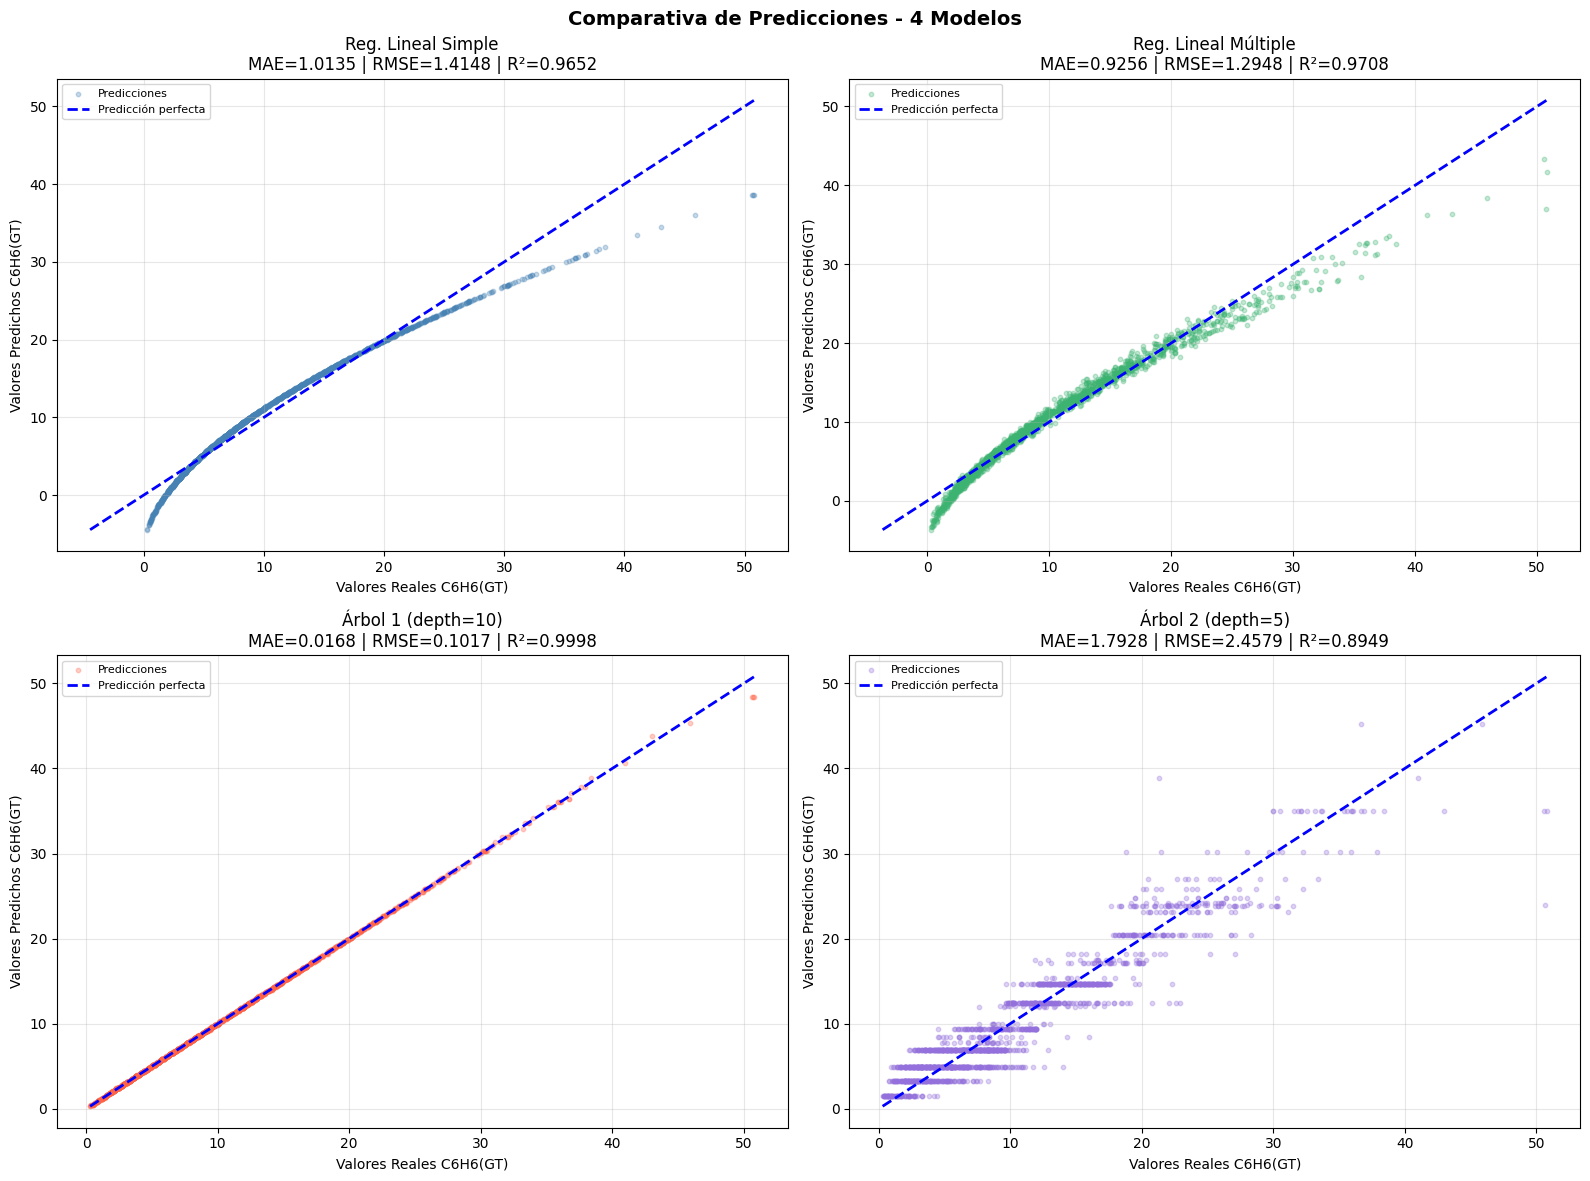

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparativa de Predicciones - 4 Modelos',
             fontsize=14, fontweight='bold')

modelos = [
    ('Reg. Lineal Simple',    y_pred_simple,   'steelblue'),
    ('Reg. Lineal Múltiple',  y_pred_multiple, 'mediumseagreen'),
    ('Árbol 1 (depth=10)',    y_pred_arbol1,   'tomato'),
    ('Árbol 2 (depth=5)',     y_pred_arbol2,   'mediumpurple')
]

for ax, (nombre, y_pred, color) in zip(axes.flatten(), modelos):

    # Puntos reales vs predichos
    ax.scatter(y_test, y_pred, alpha=0.3, color=color, s=10,
               label='Predicciones')

    # Línea perfecta
    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'b--', linewidth=2, label='Predicción perfecta')

    # Métricas en el gráfico
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    ax.set_title(f'{nombre}\nMAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}')
    ax.set_xlabel('Valores Reales C6H6(GT)')
    ax.set_ylabel('Valores Predichos C6H6(GT)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Respuesta**

| Modelo               | MAE    | RMSE   | R²     |
|----------------------|--------|--------|--------|
| Árbol 1 (depth = 10) | 0.0168 | 0.1017 | 0.9998 |
| Reg. Lineal Múltiple | 0.9256 | 1.2948 | 0.9708 |
| Reg. Lineal Simple   | 1.0135 | 1.4148 | 0.9652 |
| Árbol 2 (depth = 5)  | 1.7928 | 2.4579 | 0.8949 |

El modelo del **Árbol 1** es el mejor en base al siguiente análisis:

* Tiene métricas superiores en **MAE = 0.0168 µg/m³** su error promedio es muy bajo. Así también **R² = 0.9998** logra explicar el **99.98 %** de la varianza de los datos.

* En la gráfica se observa que sus puntos se ajustan casi perfectamente a la línea de predicción perfecta. Los otros modelos de regresión lineal muestran una curva que se aleja de dicha línea.

* El árbol captura mejor la curvatura de los datos entre **PT08.S2 (NMHC)** y **C6H6 (GT)**, ya que en el EDA se observó que esta relación no sigue una línea recta. Los modelos de regresión lineal en cambio obtienen una línea recta.

* En este caso no se presentó *overfitting* la diferencia entre **TRAIN** y **TEST** es **0.0000** en **R²**.

Se puede observar que el **Árbol 1**, con `criterion = 'poisson'`, `max_depth = 10` y utilizando todas las variables es el modelo que mejor rendimiento presenta para predecir la variable objetivo **C6H6 (GT)** en el *dataset* analizado.

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

título, autores, revista, año de publicación

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la regresión. **Técnicas de regresión** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.